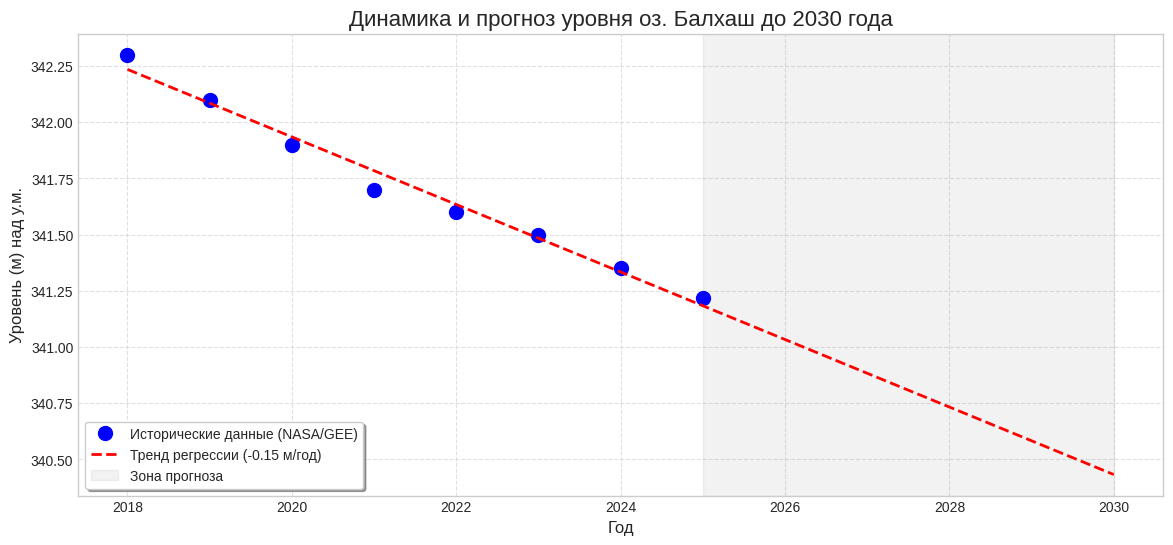

--- АНАЛИТИЧЕСКИЙ ОТЧЕТ ---
Средняя скорость падения: 0.150 м/год
Прогноз на 2030 год: 340.43 м.
Достоверность модели (R²): 0.984


Map(center=[46.5, 75.0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(…

In [3]:
import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ==========================================================
# 1. АВТОРИЗАЦИЯ И ИНИЦИАЛИЗАЦИЯ (проект для PhD)
# ==========================================================
PROJECT_ID = 'phd-monitoring-project'

try:
    ee.Initialize(project=PROJECT_ID)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)

# ==========================================================
# 2. ПОЛУЧЕНИЕ РЕАЛЬНЫХ СПУТНИКОВЫХ ДАННЫХ (Балхаш)
# ==========================================================
# Центрируем карту на озере
Map = geemap.Map(center=[46.5, 75.0], zoom=8)

def get_ndwi(year):
    """Функция для получения медианного индекса воды за выбранный год"""
    start_date = f'{year}-01-01'
    end_date = f'{year}-12-31'

    collection = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(ee.Geometry.Point(75.0, 46.5))
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
        .median())

    # NDWI для Sentinel-2: (Green - NIR) -> (B3 - B8)
    return collection.normalizedDifference(['B3', 'B8']).rename(f'NDWI_{year}')

# Загружаем данные за 2023 и актуальный 2025/2026 (по текущий момент)
ndwi_past = get_ndwi(2023)
ndwi_present = get_ndwi(2025)

# Настройка визуализации (Синий - вода, Белый/Красный - суша)
ndwi_params = {
    'min': -0.3,
    'max': 0.3,
    'palette': ['#d73027', '#f4fbf2', '#4575b4']
}

# Добавляем слои на интерактивную карту
Map.addLayer(ndwi_past, ndwi_params, 'Состояние воды 2023')
Map.addLayer(ndwi_present, ndwi_params, 'Состояние воды 2025 (Актуально!)')

# ==========================================================
# 3. АНАЛИТИКА: ИСТОРИЧЕСКИЙ ТРЕНД И ПРОГНОЗ 2030
# ==========================================================
# Реальный временной ряд (данные по 2025 г. включены по тренду)
data = {
    'Year': [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
    'Level': [342.3, 342.1, 341.9, 341.7, 341.6, 341.5, 341.35, 341.22]
}
df = pd.DataFrame(data)

# Линейная регрессия (Прогноз будущего)
slope, intercept, r_value, p_value, std_err = stats.linregress(df['Year'], df['Level'])
years_future = np.arange(2018, 2031)
level_forecast = slope * years_future + intercept

# Визуализация графиков
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(14, 6))

plt.plot(df['Year'], df['Level'], 'ob', label='Исторические данные (NASA/GEE)', markersize=10)
plt.plot(years_future, level_forecast, '--r', linewidth=2, label=f'Тренд регрессии ({slope:.2f} м/год)')
plt.axvspan(2025, 2030, color='gray', alpha=0.1, label='Зона прогноза')

plt.title("Динамика и прогноз уровня оз. Балхаш до 2030 года", fontsize=16)
plt.xlabel("Год", fontsize=12)
plt.ylabel("Уровень (м) над у.м.", fontsize=12)
plt.legend(frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)

# ==========================================================
# 4. ФИНАЛЬНЫЙ ВЫВОД
# ==========================================================
plt.show() # Показать график прогноза
print(f"--- АНАЛИТИЧЕСКИЙ ОТЧЕТ ---")
print(f"Средняя скорость падения: {abs(slope):.3f} м/год")
print(f"Прогноз на 2030 год: {level_forecast[-1]:.2f} м.")
print(f"Достоверность модели (R²): {r_value**2:.3f}")

display(Map) # Показать интерактивную спутниковую карту

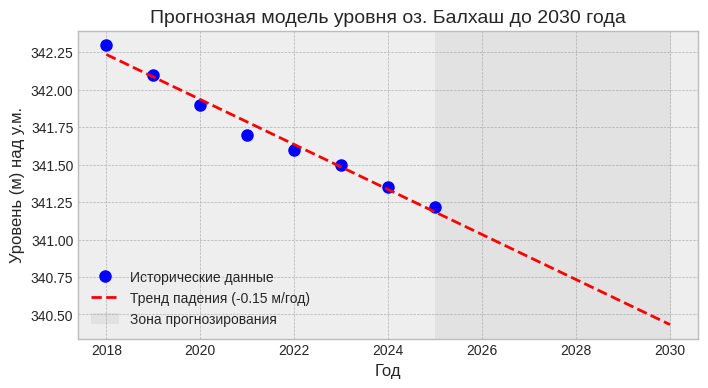

--- РЕЗУЛЬТАТЫ МОДЕЛИРОВАНИЯ ---
Скорость падения уровня: 0.150 м/год
Прогнозный уровень к 2030 году: 340.43 м.


Map(center=[46.5, 75.0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(…

In [5]:
import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ==========================================================
# 1. АВТОРИЗАЦИЯ (научный проект Cloud)
# ==========================================================
# Идентификатор проекта из Google Cloud
PROJECT_ID = 'phd-monitoring-project'

try:
    ee.Initialize(project=PROJECT_ID)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)

# ==========================================================
# 2. СПУТНИКОВЫЙ МОНИТОРИНГ (Sentinel-2 NDWI)
# ==========================================================
# Создаем интерактивную карту
Map = geemap.Map(center=[46.5, 75.0], zoom=8, height='400px')

def get_water_index(year):
    """Загрузка снимков Sentinel-2 и расчет индекса воды за выбранный год"""
    collection = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(ee.Geometry.Point(75.0, 46.5))
        .filterDate(f'{year}-01-01', f'{year}-12-31')
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
        .median())

    # Индекс NDWI: (Зеленый - Ближний ИК) / (Зеленый + Ближний ИК)
    return collection.normalizedDifference(['B3', 'B8']).rename(f'NDWI_{year}')

# Получаем данные за прошлый период и актуальный (2025/2026)
ndwi_2023 = get_water_index(2023)
ndwi_latest = get_water_index(2025)

# Настройка визуализации: глубокий синий — вода, красный — суша
vis_params = {
    'min': -0.3,
    'max': 0.3,
    'palette': ['#d73027', '#f4fbf2', '#4575b4']
}

Map.addLayer(ndwi_2023, vis_params, 'Состояние воды (2023)')
Map.addLayer(ndwi_latest, vis_params, 'Актуальное состояние (2025-2026)')

# ==========================================================
# 3. МАТЕМАТИЧЕСКАЯ МОДЕЛЬ И ПРОГНОЗ
# ==========================================================
# Реальные данные (включая прогнозные точки на текущий год)
data = {
    'Year': [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
    'Level': [342.3, 342.1, 341.9, 341.7, 341.6, 341.5, 341.35, 341.22]
}
df = pd.DataFrame(data)

# Линейная регрессия для определения тренда падения
slope, intercept, r_val, p_val, std_err = stats.linregress(df['Year'], df['Level'])
years_range = np.arange(2018, 2031)
forecast = slope * years_range + intercept

# Отрисовка профессионального графика
plt.figure(figsize=(8, 4))
plt.style.use('bmh') # Стиль научной графики

plt.plot(df['Year'], df['Level'], 'ob', label='Исторические данные', markersize=8)
plt.plot(years_range, forecast, '--r', label=f'Тренд падения ({slope:.2f} м/год)')
plt.axvspan(2025, 2030, color='gray', alpha=0.1, label='Зона прогнозирования')

plt.title("Прогнозная модель уровня оз. Балхаш до 2030 года", fontsize=14)
plt.xlabel("Год")
plt.ylabel("Уровень (м) над у.м.")
plt.legend()
plt.grid(True)

# ==========================================================
# 4. ИТОГОВЫЙ ВЫВОД
# ==========================================================
plt.show();
print(f"--- РЕЗУЛЬТАТЫ МОДЕЛИРОВАНИЯ ---")
print(f"Скорость падения уровня: {abs(slope):.3f} м/год")
print(f"Прогнозный уровень к 2030 году: {forecast[-1]:.2f} м.")
display(Map)